Task 1 - Importing all the required libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats
from scipy.stats import skew
%matplotlib inline

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('ggplot') #use graphic plot
plt.rcParams['figure.figsize'] = (12,8) #specific parameters

Task 2 - Load the Data

The Advertisement dataset captures sales revenue generated with respect to advertisement spend across multiple channels like TV, Radio and Newspaper

In [ ]:
df = pd.read_csv('Advertising.csv')
df.head(10)

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,10.6


In [ ]:
df.info

<bound method DataFrame.info of         TV  radio  newspaper  sales
0    230.1   37.8       69.2   22.1
1     44.5   39.3       45.1   10.4
2     17.2   45.9       69.3    9.3
3    151.5   41.3       58.5   18.5
4    180.8   10.8       58.4   12.9
..     ...    ...        ...    ...
195   38.2    3.7       13.8    7.6
196   94.2    4.9        8.1    9.7
197  177.0    9.3        6.4   12.8
198  283.6   42.0       66.2   25.5
199  232.1    8.6        8.7   13.4

[200 rows x 4 columns]>

Task 3 - Relationship between Features and Response

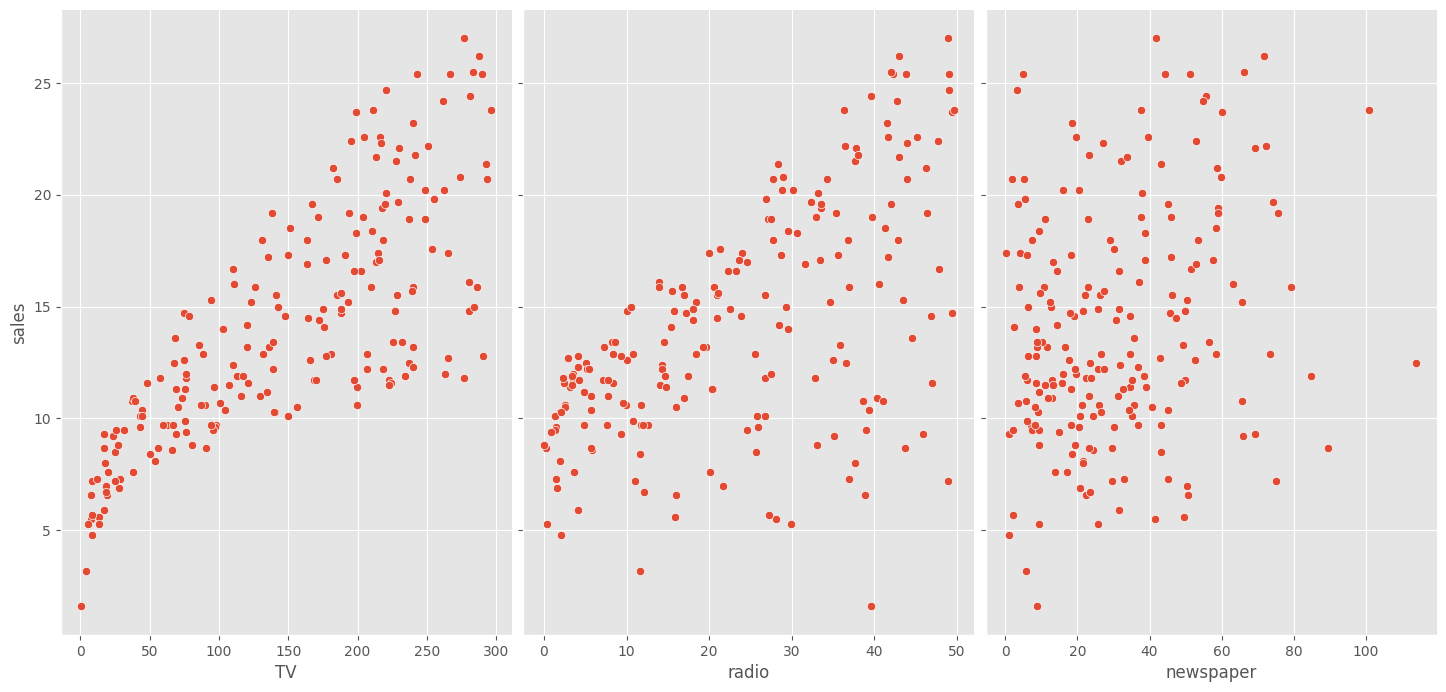

In [ ]:
sns.pairplot(df, x_vars=['TV', 'radio', 'newspaper'], y_vars = 'sales', height = 7, aspect = 0.7)

Task 4 - Multiple Linear Regression Model - Estimating Coefficients

In [ ]:
from sklearn.linear_model import LinearRegression
x = df.drop('sales', axis = 1) #we drop output i.e sales, also it is now independent variable (input)
y = df['sales'] #dependent variable (output)

#Traning the Model

lm1 = LinearRegression()
lm1.fit(x,y)

print(lm1.intercept_)
print(lm1.coef_)

2.938889369459412
[ 0.04576465  0.18853002 -0.00103749]


In [ ]:
#store the features
feature_name = ['TV', 'radio', 'newspaper']

#Get the regression coefficients
coefficients = lm1.coef_

#Creating a dictionary to map each coloumb to its coefficient
feature_coefficients = dict(zip(feature_name, coefficients))

#Display the coefficients
feature_coefficients

{'TV': np.float64(0.0457646454553976),
 'radio': np.float64(0.18853001691820448),
 'newspaper': np.float64(-0.0010374930424763285)}

<Axes: >

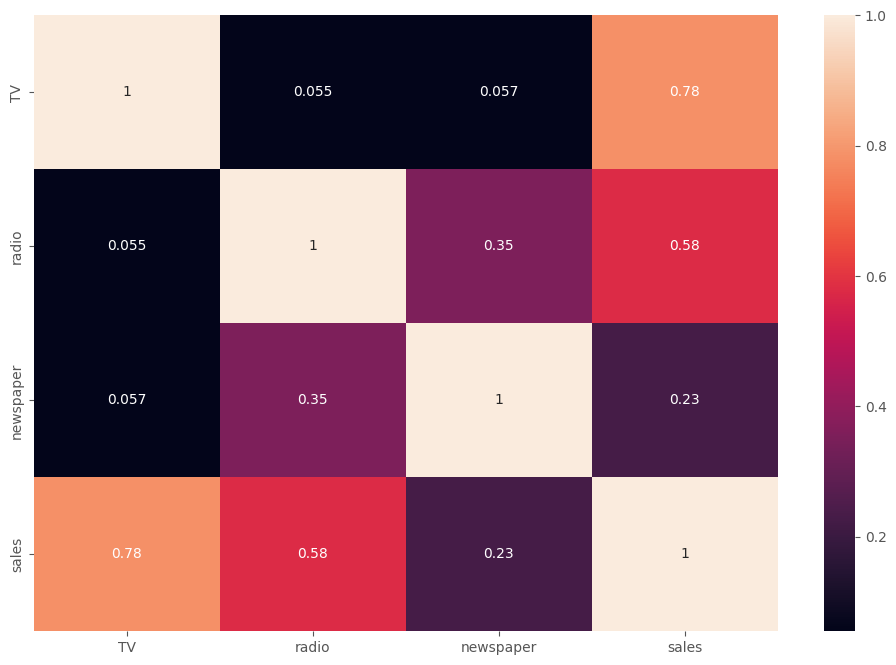

In [ ]:
sns.heatmap(df.corr(), annot = True)

Task 5 - Feature Selection

In [ ]:
from sklearn.metrics import r2_score

#Model 1 using TV and radio
X_tv_radio = df[['TV', 'radio']]

#Initialize the model
lm2 = LinearRegression()

#Training the Model on full dataset
lm2.fit(X_tv_radio, y)

#Predict the sales using train model
lm2_pred = lm2.predict(X_tv_radio)

#Calculate R2 Score for model evalution
r2_tv_radio = r2_score(y, lm2_pred)
print("R2 score using TV and Radio : ", r2_tv_radio)

R2 score using TV and Radio :  0.8971942610828957


In [ ]:
#Model 2 - Using TV, Radio and Newspaper
X_all_features = df[['TV', 'radio', 'newspaper']]
lm3 = LinearRegression()
lm3.fit(X_all_features, y)
lm3_pred = lm3.predict(X_all_features)
r2_all_features = r2_score(y, lm3_pred)
print("R2 score using TV, Radio and Newspaper : ", r2_all_features)

R2 score using TV, Radio and Newspaper :  0.8972106381789522


Here the change in R2 Score of both model is so minimal it is not appropriate to take 3 features as the outcome of it is soo minimum so we are going to use the 2 feature model further




Task 6 - Model Evalution using Train/Test Dataset

Here we are checking using Train/Test split with RSME whether to keep newspaper as feature

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

X = df.drop('sales', axis=1)
y = df['sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

lm4 = LinearRegression()
lm4.fit(X_train, y_train)
lm4_pred = lm4.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, lm4_pred))
print("RMSE : ", rmse)

r2_score = r2_score(y_test, lm4_pred)
print("R2 score : ", r2_score)

RMSE :  1.404651423032895
R2 score :  0.9156213613792232


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

X = df[['TV', 'radio']]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

lm5 = LinearRegression()
lm5.fit(X_train, y_train)
lm5_pred = lm5.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, lm5_pred))
print("RMSE : ", rmse)

r2_score = r2_score(y_test, lm5_pred)
print("R2 score : ", r2_score)

RMSE :  1.3879034699382888
R2 score :  0.9176214942248907


Task 7 - Model Diagnostics

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


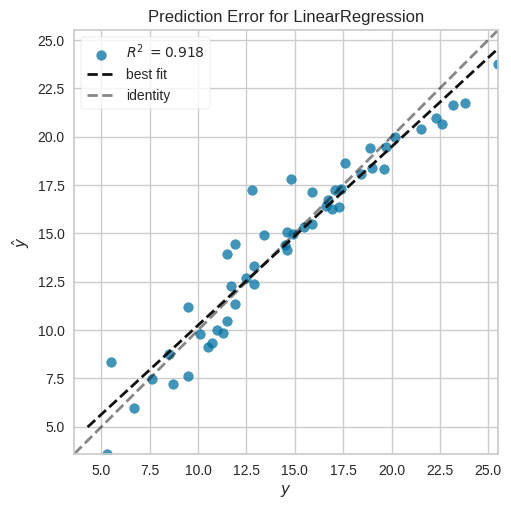

<Axes: title={'center': 'Prediction Error for LinearRegression'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [ ]:
from yellowbrick.regressor import ResidualsPlot, PredictionError

visualizer = PredictionError(lm5).fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()

Task 8 - Interaction Effect (Synergy)

In [ ]:
from sklearn.metrics import r2_score

#Create interaction feature
df['tv_radio_interaction'] = df['radio']*df['TV']

#Select the feature including the interaction term
X = df[['TV', 'radio', 'tv_radio_interaction']]
y = df['sales']

#Split the data into traning and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

#Trainig teh interaction model
interaction_model = LinearRegression()
interaction_model.fit(X_train, y_train)

y_pred = interaction_model.predict(X_test)

print("RMSE : ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score : ", r2_score(y_test, y_pred))

RMSE :  0.7011871137164328
R2 Score :  0.978973681468126


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


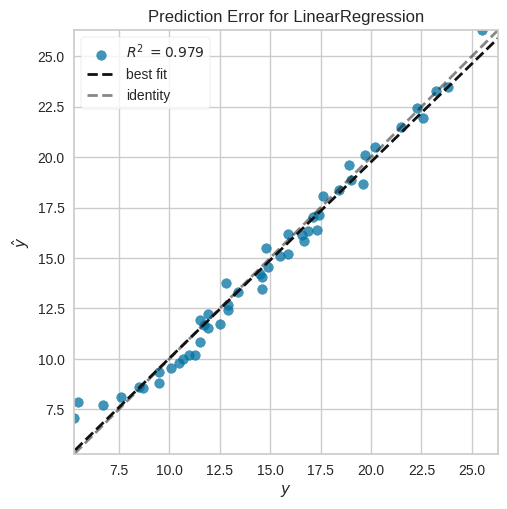

<Axes: title={'center': 'Prediction Error for LinearRegression'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [ ]:
from yellowbrick.regressor import ResidualsPlot, PredictionError

visualizer = PredictionError(interaction_model).fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()

Conclusion